# 09 — Лимит активных уровней (top-M по силе) + forward-путь

До сих пор: устаревание по возрасту (LIFE=720) было, но число активных уровней не
ограничено → на k=2 их десятки (нереалистично; слабые шумят поверх сильных). Идея
(user): держать максимум **M** уровней, оставляя САМЫЕ СИЛЬНЫЕ (больше всего слитых
фракталов). nb08 показал, что edge сидит в сильных → cap должен и реалистичнее, и резче.

Тест: edge при M∈{3,5,8,∞}; forward-доходность по ГОРИЗОНТАМ (1..48h) для top-M
уровней vs matched-контроль; **train 2024 / test 2025-26** (честный OOS).

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd
rng = np.random.default_rng(0)
full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::4][:35]
START, END, TF = "2024-01-01", "2026-07-01", "1h"
TOL = 0.0015; CD = 6; LIFE = 720; W = 720; NMERGE = 0.004; COST = 0.0015
HZ = [1, 2, 4, 6, 12, 24, 48]; HMAX = 48
SPLIT = pd.Timestamp("2025-01-01", tz="UTC")
print(len(UNIV), "symbols")

35 symbols


In [2]:
def fractals(df, k=2):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i-k:i+k+1]; wL = l[i-k:i+k+1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def merge_centroid(prices, N):
    if len(prices) == 0: return []
    cen = [[p, 1] for p in sorted(prices)]
    while len(cen) > 1:
        gaps = [(cen[i+1][0]-cen[i][0])/cen[i][0] for i in range(len(cen)-1)]
        j = int(np.argmin(gaps))
        if gaps[j] > N: break
        p0, n0 = cen[j]; p1, n1 = cen[j+1]
        cen[j] = [(p0*n0+p1*n1)/(n0+n1), n0+n1]; del cen[j+1]
    return [(p, s) for p, s in cen]

def build_segments(df, k=2, R=24, life=LIFE, N=NMERGE):
    """All zones with (price, a=recompute idx, b, strength). Cap applied later per-a."""
    hi, lo = fractals(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); conf = []
    for i in np.where(hi)[0]: conf.append((i+k, h[i]))
    for i in np.where(lo)[0]: conf.append((i+k, l[i]))
    conf = np.array(sorted(conf)) if conf else np.empty((0, 2)); segs = []
    for r in range(k, n, R):
        if len(conf) == 0: break
        m = (conf[:, 0] <= r) & (conf[:, 0] > r - life)
        if m.sum() < 3: continue
        for price, strg in merge_centroid(conf[m, 1], N):
            if strg >= 3: segs.append((price, r, min(r+R, n), strg))
    return segs

def cap_topM(segs, M):
    """Keep only the M strongest zones per recompute window (a). M=None -> all."""
    if M is None: return segs
    by_a = {}
    for s in segs: by_a.setdefault(s[1], []).append(s)
    out = []
    for a, lst in by_a.items():
        out.extend(sorted(lst, key=lambda z: -z[3])[:M])
    return out

def touches(df, segs, tol=TOL):
    c = df["close"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy()
    best = {}
    for L, a, b, strg in segs:
        a = max(a, 1)
        for tt in range(a, b):
            if c[tt-1] < L*(1-tol) and h[tt] >= L*(1-tol):
                dd = abs(h[tt]-L)/L; key=(tt,"res")
                if key not in best or dd < best[key][1]: best[key] = (L, dd, strg)
            elif c[tt-1] > L*(1+tol) and l[tt] <= L*(1+tol):
                dd = abs(l[tt]-L)/L; key=(tt,"sup")
                if key not in best or dd < best[key][1]: best[key] = (L, dd, strg)
    out = sorted((tt, side, L, strg) for (tt, side), (L, dd, strg) in best.items())
    kept = []; last = -10**9
    for tt, side, L, strg in out:
        if tt - last >= CD: kept.append((tt, side, L, strg)); last = tt
    return kept

In [3]:
MS = [3, 5, 8, None]
rows = []
for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, TF)
    if len(df) < W + 200: continue
    c = df["close"].to_numpy(); n = len(df); ts = df.index
    hi_w = pd.Series(df["high"]).rolling(W).max().to_numpy()
    lo_w = pd.Series(df["low"]).rolling(W).min().to_numpy(); span = hi_w - lo_w
    base = [s for s in build_segments(df) if s[1] >= W and span[s[1]] > 0]
    if not base: continue
    for M in MS:
        segs = cap_topM(base, M)
        pos = np.array([(L-lo_w[a])/span[a] for (L, a, b, st) in segs])
        posp = rng.permutation(pos)
        matched = [(lo_w[a]+posp[i]*span[a], a, b, st) for i, (L, a, b, st) in enumerate(segs)]
        for kind, ss in [("real", segs), ("matched", matched)]:
            for tt, side, L, strg in touches(df, ss):
                if tt < W or tt + HMAX >= n: continue
                row = dict(M=str(M), kind=kind, period=("train" if ts[tt] < SPLIT else "test"))
                for hh in HZ:
                    rr = c[tt+hh]/c[tt]-1.0
                    row[f"h{hh}"] = rr if side == "sup" else -rr
                rows.append(row)
    if (si+1) % 10 == 0: print(f"  {si+1}/{len(UNIV)}")
E = pd.DataFrame(rows)
print("\nrows:", len(E))
print(E.groupby(["M","kind"]).size().unstack().to_string())

  10/35


  20/35


  30/35



rows: 369692
kind  matched   real
M                   
3       23909  22889
5       35008  32088
8       47281  43197
None    83159  82161


In [4]:
# (1) net edge vs M at 12h & 24h, real, train & test
print("=== net signed edge (gross - cost) by M, real only ===")
for per in ["train", "test"]:
    sub = E[(E.kind=="real") & (E.period==per)]
    t = sub.groupby("M").agg(n=("h12","size"),
          net12=("h12", lambda s:(s.mean()-COST)*100),
          net24=("h24", lambda s:(s.mean()-COST)*100),
          ms12=("h12", lambda s: s.mean()/s.std() if s.std()>0 else np.nan))
    t = t.reindex(["3","5","8","None"])
    print(f"\n[{per}]"); print(t.round(3).to_string())

=== net signed edge (gross - cost) by M, real only ===

[train]
          n  net12  net24   ms12
M                               
3      9224 -0.118 -0.134  0.009
5     12836 -0.098 -0.081  0.014
8     17277 -0.048 -0.021  0.028
None  33393 -0.127 -0.153  0.006

[test]
          n  net12  net24   ms12
M                               
3     13665 -0.208 -0.131 -0.015
5     19252 -0.173 -0.122 -0.006
8     25920 -0.148 -0.094  0.001
None  48768 -0.121 -0.063  0.008


[saved] notebooks\levels\_out\09_topM_path.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/09_topM_path.png')

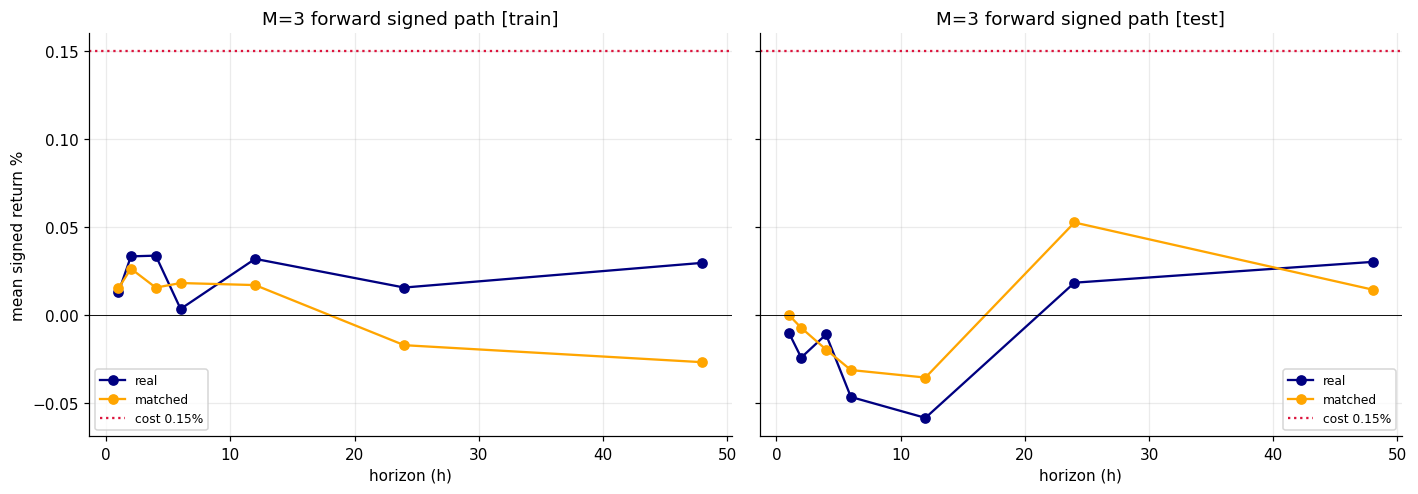

In [5]:
# (2) forward path by horizon for M=3 (tightest), real vs matched, train vs test
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for j, per in enumerate(["train", "test"]):
    for kind, col in [("real","navy"), ("matched","orange")]:
        sub = E[(E.M=="3") & (E.kind==kind) & (E.period==per)]
        path = [sub[f"h{h}"].mean()*100 for h in HZ]
        ax[j].plot(HZ, path, "o-", color=col, label=kind)
    ax[j].axhline(COST*100, color="crimson", ls=":", label=f"cost {COST*100:.2f}%")
    ax[j].axhline(0, color="k", lw=0.6)
    ax[j].set_title(f"M=3 forward signed path [{per}]"); ax[j].set_xlabel("horizon (h)"); ax[j].legend(fontsize=8)
ax[0].set_ylabel("mean signed return %")
show("09_topM_path")

## Verdict

- Если **меньший M → выше edge** (фокус на сильнейших) И test повторяет train → cap
  работает, top-M сильных уровней несут реальный сигнал.
- Если **real-путь устойчиво над cost-линией и над matched** на ОБА периода → впервые
  торгуемо. Если edge есть на train, но в test исчезает → переобучение на 2024.
- matched всегда рядом с нулём = контроль расположения; разрыв real−matched = чистый эффект уровня.

96 level-tracks over the window (max strength 28)
[saved] notebooks\levels\_out\09_topM_lines.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/09_topM_lines.png')

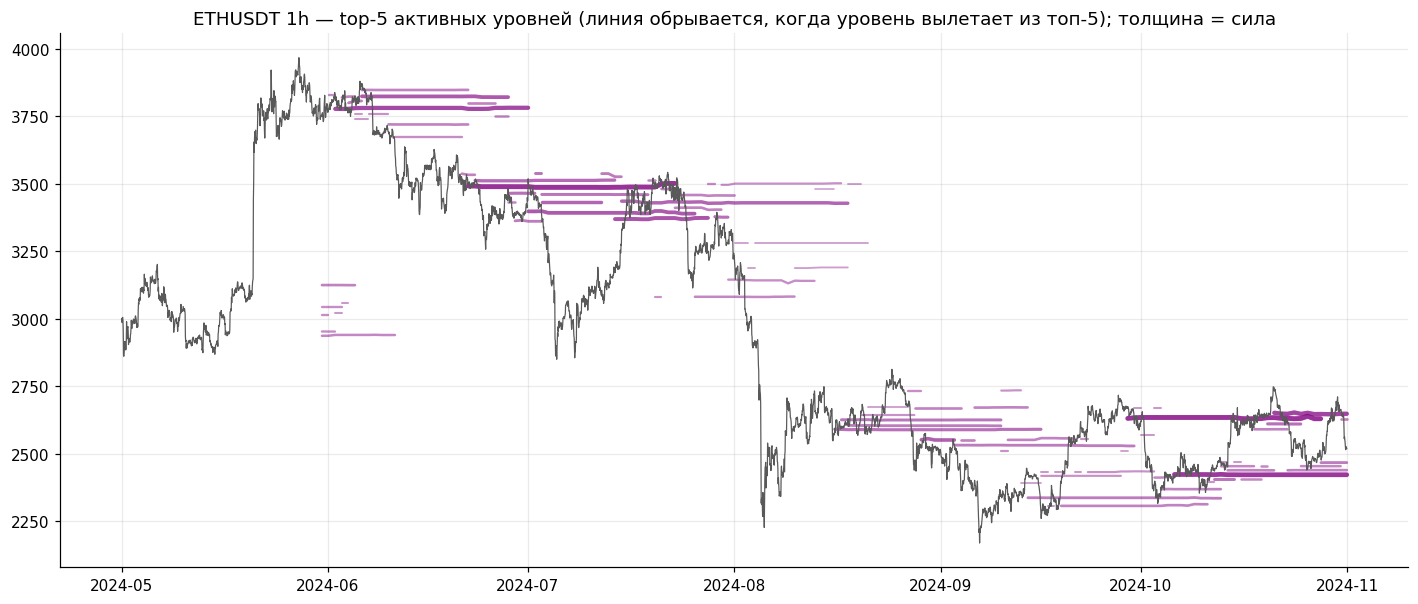

In [6]:
# --- viz: M=5 levels as lines that STOP when a level deactivates ---
# Track-link capped zones across recompute windows by price proximity: a level is
# ONE continuous line while it stays in the top-M; the line ends the window it
# drops out (booted by a stronger level, or its fractals age out of the window).
SYMV, M_VIZ = "ETHUSDT", 5
dv = ohlcv(SYMV, "2024-05-01", "2024-11-01", TF)
nv = len(dv); tsv = dv.index
capped = [s for s in cap_topM(build_segments(dv), M_VIZ) if s[1] >= W]
byA = {}
for (price, a, b, st) in capped:
    byA.setdefault(a, []).append((price, b, st))

tracks, active = [], []
for a in sorted(byA):
    used = [False] * len(active); nxt = []
    for (price, b, st) in sorted(byA[a], key=lambda x: -x[2]):   # strongest first
        best, bd = -1, 1e9
        for i, tr in enumerate(active):
            if used[i]:
                continue
            d = abs(price - tr["pref"]) / tr["pref"]
            if d < bd and d <= NMERGE:
                bd, best = d, i
        if best >= 0:
            tr = active[best]; used[best] = True
            tr["pts"].append((a, price)); tr["last_b"] = b; tr["pref"] = price
            tr["st"] = max(tr["st"], st); nxt.append(tr)
        else:
            tr = dict(pts=[(a, price)], last_b=b, pref=price, st=st)
            tracks.append(tr); nxt.append(tr)
    active = nxt   # tracks not matched this window are deactivated -> their line ends

smax = max(tr["st"] for tr in tracks)
fig, ax = plt.subplots(figsize=(13, 5.6))
ax.plot(tsv, dv["close"], lw=0.8, color="0.35", zorder=3)
for tr in tracks:
    xs = [tsv[a] for a, _ in tr["pts"]] + [tsv[min(tr["last_b"] - 1, nv - 1)]]
    ys = [pr for _, pr in tr["pts"]] + [tr["pts"][-1][1]]
    f = (tr["st"] - 3) / max(1, smax - 3)
    ax.plot(xs, ys, color="purple", lw=0.6 + 2.6 * f, alpha=0.25 + 0.55 * f,
            solid_capstyle="round", zorder=2)
print(f"{len(tracks)} level-tracks over the window (max strength {smax})")
ax.set_title(f"{SYMV} 1h — top-{M_VIZ} активных уровней (линия обрывается, когда уровень вылетает из топ-{M_VIZ}); толщина = сила")
show("09_topM_lines")

[saved] notebooks\levels\_out\09_topM_1m_zoom.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/09_topM_1m_zoom.png')

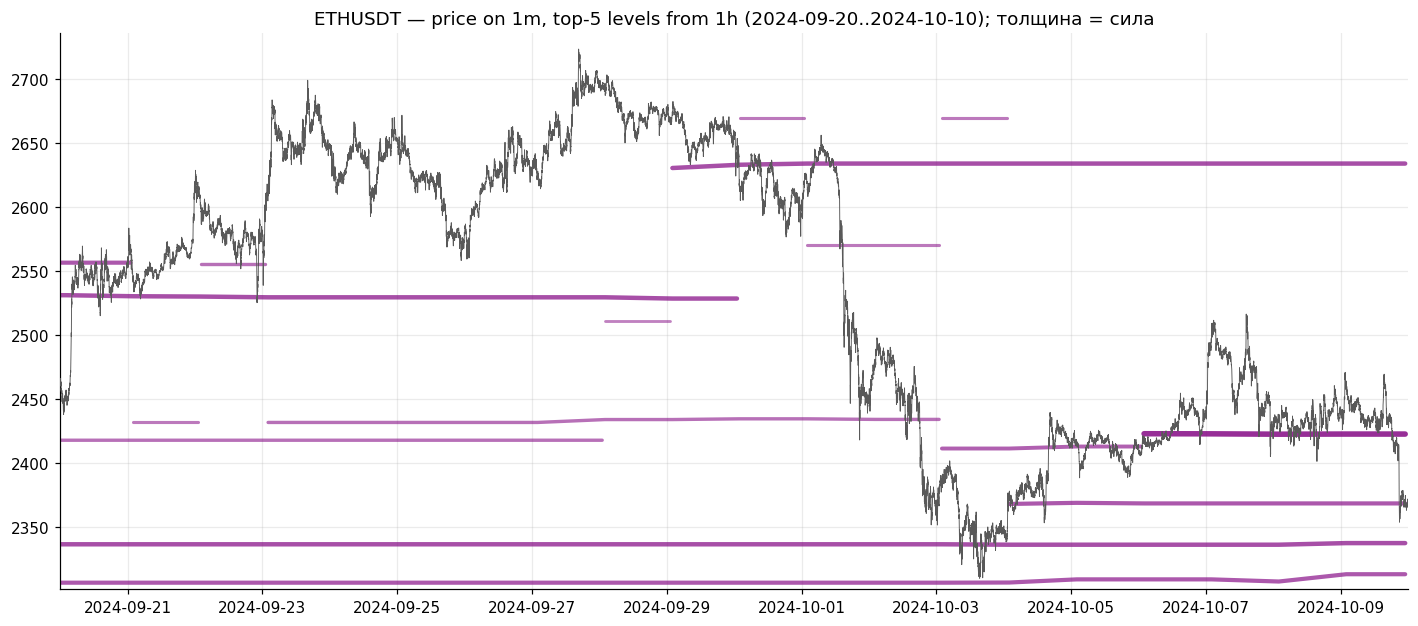

In [7]:
# --- zoomed 1m view: same top-5 1h levels, price on 1-minute bars ---
# Levels defined on 1h (meaningful); price drawn on 1m in a ~3-week window so the
# alignment of a level line vs the swings that formed it is visible up close.
# NOTE the rightward lag is causal, not a data shift: a confluence level only
# enters the top-5 after several fractals stack at that price, which is AFTER the
# price region that seeded it; the line is drawn from that confirmation onward.
SYMV, M_VIZ = "ETHUSDT", 5
HIST, ZA, ZB = "2024-07-15", "2024-09-20", "2024-10-10"
zlo = pd.Timestamp(ZA, tz="UTC"); zhi = pd.Timestamp(ZB, tz="UTC")
dh = ohlcv(SYMV, HIST, ZB, TF); nh = len(dh); th = dh.index
capped = [s for s in cap_topM(build_segments(dh), M_VIZ) if s[1] >= W]
byA = {}
for (price, a, b, st) in capped:
    byA.setdefault(a, []).append((price, b, st))
tracks, active = [], []
for a in sorted(byA):
    used = [False] * len(active); nxt = []
    for (price, b, st) in sorted(byA[a], key=lambda x: -x[2]):
        best, bd = -1, 1e9
        for i, tr in enumerate(active):
            if used[i]:
                continue
            d = abs(price - tr["pref"]) / tr["pref"]
            if d < bd and d <= NMERGE:
                bd, best = d, i
        if best >= 0:
            tr = active[best]; used[best] = True
            tr["pts"].append((a, price)); tr["last_b"] = b; tr["pref"] = price
            tr["st"] = max(tr["st"], st); nxt.append(tr)
        else:
            tr = dict(pts=[(a, price)], last_b=b, pref=price, st=st); tracks.append(tr); nxt.append(tr)
    active = nxt

dm = ohlcv(SYMV, ZA, ZB, "1min")
ymin, ymax = dm["low"].min(), dm["high"].max()
smax = max(tr["st"] for tr in tracks)
fig, ax = plt.subplots(figsize=(13, 5.8))
ax.plot(dm.index, dm["close"], lw=0.6, color="0.35", zorder=3)
for tr in tracks:
    x0 = th[tr["pts"][0][0]]; x1 = th[min(tr["last_b"] - 1, nh - 1)]
    if x1 < zlo or x0 > zhi:           # skip tracks not visible in the window
        continue
    xs = [th[a] for a, _ in tr["pts"]] + [x1]
    ys = [pr for _, pr in tr["pts"]] + [tr["pts"][-1][1]]
    f = (tr["st"] - 3) / max(1, smax - 3)
    ax.plot(xs, ys, color="purple", lw=0.8 + 3.0 * f, alpha=0.3 + 0.55 * f,
            solid_capstyle="round", zorder=2)
ax.set_xlim(zlo, zhi); ax.set_ylim(ymin * 0.997, ymax * 1.003)
ax.set_title(f"{SYMV} — price on 1m, top-{M_VIZ} levels from 1h ({ZA}..{ZB}); толщина = сила")
show("09_topM_1m_zoom")